# DL4ES: Sigmoid / Tanh в очень глубокой MLP — демонстрация проблем обучения

Цель ноутбука:
- На простом синтетическом датасете показать, **как насыщение** в `sigmoid` и `tanh` приводит к деградации градиентов в очень глубокой полносвязной сети.
- Показать, что замена на `ReLU` резко улучшает проходимость градиента и обучаемость **без обсуждения недостатков ReLU**.

В конце будут:
- кривые обучения;
- статистики активаций по слоям (mean/var + доля насыщенных нейронов);
- нормы градиентов по слоям.


In [1]:
# === Импорты и воспроизводимость ===
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 1) Синтетический датасет

Берём простую **регрессию**: вход `x ∈ R^d`, цель `y` — нелинейная функция от `x`.

Важно: датасет должен быть достаточно “очевидным”, чтобы глубокая сеть в принципе могла его аппроксимировать.
Возьмём комбинацию синусов + билинейного члена.


In [4]:
# === Датасет: нелинейная регрессия ===
def make_dataset(n_train=4096, n_val=1024, d=16, noise_std=0.05):
    # X ~ N(0, 1)
    X_train = np.random.randn(n_train, d).astype(np.float32)
    X_val   = np.random.randn(n_val, d).astype(np.float32)

    # Нелинейная целевая функция (скалярная)
    def f(X):
        # смесь синусов и взаимодействий признаков
        s1 = np.sin(X[:, 0]) + 0.5*np.sin(2*X[:, 1])
        s2 = 0.25*(X[:, 2]*X[:, 3]) - 0.1*(X[:, 4]**2)
        s3 = 0.2*np.tanh(X[:, 5]) + 0.15*np.sin(X[:, 6] + X[:, 7])
        return (s1 + s2 + s3).astype(np.float32)

    y_train = f(X_train) + noise_std*np.random.randn(n_train).astype(np.float32)
    y_val   = f(X_val)   + noise_std*np.random.randn(n_val).astype(np.float32)

    # reshape to (N, 1)
    y_train = y_train.reshape(-1, 1)
    y_val   = y_val.reshape(-1, 1)

    return (torch.from_numpy(X_train), torch.from_numpy(y_train),
            torch.from_numpy(X_val),   torch.from_numpy(y_val))

X_train, y_train, X_val, y_val = make_dataset()
X_train.shape, y_train.shape


(torch.Size([4096, 16]), torch.Size([4096, 1]))

In [5]:
# Быстрый sanity-check: посмотрим диапазоны
print("X_train mean/std:", X_train.mean().item(), X_train.std().item())
print("y_train mean/std:", y_train.mean().item(), y_train.std().item())


X_train mean/std: 0.001304467092268169 0.9986587166786194
y_train mean/std: -0.11907708644866943 0.8146888017654419


## 2) Очень глубокая MLP

Конструкция:
- вход `d=16`
- **очень много слоёв** (например, 50)
- ширина слоёв 128
- активация: `sigmoid` / `tanh` / `relu`

Мы соберём инструментирование:
- сохранение активаций по слоям (mean/var);
- оценка доли насыщенных нейронов для sigmoid/tanh;
- нормы градиентов параметров по слоям.


In [6]:
@dataclass
class ActStats:
    layer: int
    mean: float
    var: float
    sat_frac: float  # доля насыщенных (для sigmoid/tanh), иначе NaN

In [8]:
class DeepMLP(nn.Module):
    def __init__(self, d_in=16, width=128, depth=50, act="tanh"):
        super().__init__()
        assert act in ["sigmoid", "tanh", "relu"]
        self.act_name = act
        self.depth = depth

        layers = []
        in_dim = d_in
        for _ in range(depth):
            layers.append(nn.Linear(in_dim, width))
            in_dim = width
        self.hidden = nn.ModuleList(layers)
        self.out = nn.Linear(width, 1)

        # Хранилище последнего forward (для анализа распределений)
        self._last_act_stats = []

    def act(self, x):
        if self.act_name == "sigmoid":
            return torch.sigmoid(x)
        if self.act_name == "tanh":
            return torch.tanh(x)
        return F.relu(x)

    @torch.no_grad()
    def last_activation_stats(self):
        return self._last_act_stats

    def forward(self, x, collect_stats=False):
        self._last_act_stats = []
        h = x
        for i, lin in enumerate(self.hidden):
            z = lin(h)
            a = self.act(z)

            if collect_stats:
                mean = a.mean().item()
                var  = a.var(unbiased=False).item()

                if self.act_name == "sigmoid":
                    # "Насыщение": производная sigmoid = s(1-s) близка к 0 при s ~ 0 или 1
                    # Практически: считаем насыщенными значения близкие к 0 или 1
                    sat = ((a < 0.05) | (a > 0.95)).float().mean().item()
                elif self.act_name == "tanh":
                    # Насыщение: tanh близок к -1 или 1
                    sat = (a.abs() > 0.95).float().mean().item()
                else:
                    sat = float("nan")

                self._last_act_stats.append(ActStats(i, mean, var, sat))

            h = a
        return self.out(h)

In [9]:
def count_params(m: nn.Module):
    return sum(p.numel() for p in m.parameters())

In [10]:
# Конфигурация "очень глубоко"
D_IN = X_train.shape[1]
WIDTH = 128
DEPTH = 50

In [11]:
for a in ["sigmoid", "tanh", "relu"]:
    m = DeepMLP(d_in=D_IN, width=WIDTH, depth=DEPTH, act=a)
    print(a, "params:", count_params(m))

sigmoid params: 811393
tanh params: 811393
relu params: 811393


## 3) Обучение и сбор метрик

Мы будем обучать одну и ту же архитектуру с разными активациями.

Метрики:
- `train_loss`, `val_loss`
- `activation mean/var` по слоям на фиксированном батче
- `saturation fraction` по слоям (sigmoid/tanh)
- `gradient norm` по слоям (норма градиента весов каждого слоя)


In [6]:
from torch.utils.data import TensorDataset, DataLoader

In [7]:
train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=512, shuffle=False)

In [8]:
def eval_loss(model, loader):
    model.eval()
    total = 0.0
    n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = F.mse_loss(pred, yb, reduction="sum")
            total += loss.item()
            n += xb.size(0)
    return total / n

In [9]:
def grad_norms_by_layer(model: DeepMLP):
    # Возвращаем норму градиента весов для каждого Linear в hidden + out
    norms = []
    for lin in model.hidden:
        if lin.weight.grad is None:
            norms.append(float("nan"))
        else:
            norms.append(lin.weight.grad.detach().norm().item())
    # выходной слой
    if model.out.weight.grad is None:
        norms.append(float("nan"))
    else:
        norms.append(model.out.weight.grad.detach().norm().item())
    return norms

In [10]:
def train_one(model, epochs=50, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "act_stats": [],      # список списков ActStats
        "grad_norms": [],     # список массивов норм
    }

    # фиксированный батч для диагностики распределений
    xb_diag, yb_diag = next(iter(train_loader))
    xb_diag = xb_diag.to(device)
    yb_diag = yb_diag.to(device)

    for ep in tqdm(range(1, epochs + 1), total=epochs):
        model.train()
        total = 0.0
        n = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            opt.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = F.mse_loss(pred, yb)
            loss.backward()
            opt.step()

            total += loss.item() * xb.size(0)
            n += xb.size(0)

        train_loss = total / n
        val_loss = eval_loss(model, val_loader)

        # диагностика: распределения активаций
        model.eval()
        with torch.no_grad():
            _ = model(xb_diag, collect_stats=True)
            act_stats = model.last_activation_stats()

        # диагностика: нормы градиентов по слоям на диагностическом батче
        model.train()
        opt.zero_grad(set_to_none=True)
        pred = model(xb_diag)
        loss = F.mse_loss(pred, yb_diag)
        loss.backward()
        gnorms = grad_norms_by_layer(model)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["act_stats"].append(act_stats)
        history["grad_norms"].append(gnorms)

#         if ep in [1, 2, 3, 5, 10, 20, 50]:
#             print(f"ep {ep:>3d} | train {train_loss:.4f} | val {val_loss:.4f}")

    return model, history

## 4) Запуск экспериментов: sigmoid vs tanh vs ReLU

ВНИМАНИЕ: глубина 50 слоёв — это специально “чересчур”, чтобы эффекты проявились наглядно.


In [11]:
EPOCHS = 50
LR = 1e-3

results = {}
for act in ["sigmoid", "tanh", "relu"]:
    print("\n" + "="*80)
    print("Activation:", act)
    model = DeepMLP(d_in=D_IN, width=WIDTH, depth=DEPTH, act=act)
    trained_model, hist = train_one(model, epochs=EPOCHS, lr=LR)
    results[act] = {"model": trained_model, "hist": hist}



Activation: sigmoid


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:50<00:00,  1.01s/it]



Activation: tanh


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:50<00:00,  1.01s/it]



Activation: relu


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:46<00:00,  1.09it/s]


## 5) Кривые обучения

Смотрим, обучается ли сеть и насколько быстро.


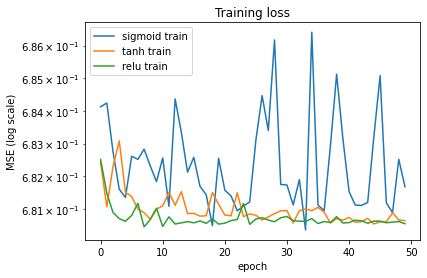

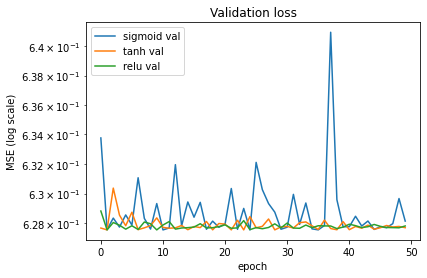

In [20]:
plt.figure()
for act in ["sigmoid", "tanh", "relu"]:
    h = results[act]["hist"]
    plt.plot(h["train_loss"], label=f"{act} train")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE (log scale)")
plt.title("Training loss")
plt.legend()
plt.show()


plt.figure()
for act in ["sigmoid", "tanh", "relu"]:
    h = results[act]["hist"]
    plt.plot(h["val_loss"],   label=f"{act} val")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE (log scale)")
plt.title("Validation loss")
plt.legend()
plt.show()

## 6) Статистики активаций по слоям: mean / var

Берём последнюю эпоху (или любую интересную) и смотрим, как распределения “живут” по глубине сети.


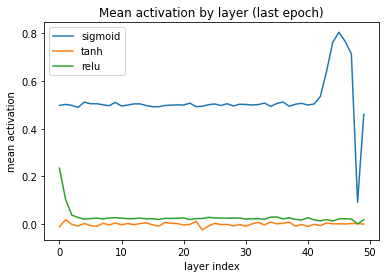

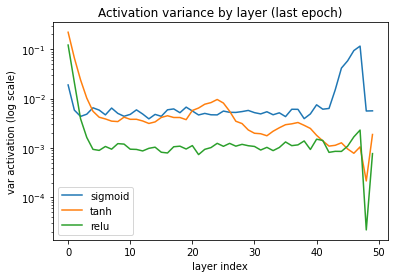

In [13]:
def extract_layer_series(act_stats_list):
    # act_stats_list: список ActStats для одной эпохи
    layers = [s.layer for s in act_stats_list]
    means  = [s.mean for s in act_stats_list]
    vars_  = [s.var for s in act_stats_list]
    sats   = [s.sat_frac for s in act_stats_list]
    return layers, means, vars_, sats

epoch_to_show = -1  # последняя эпоха

# mean
plt.figure()
for act in ["sigmoid", "tanh", "relu"]:
    act_stats = results[act]["hist"]["act_stats"][epoch_to_show]
    layers, means, vars_, sats = extract_layer_series(act_stats)
    plt.plot(layers, means, label=act)
plt.xlabel("layer index")
plt.ylabel("mean activation")
plt.title("Mean activation by layer (last epoch)")
plt.legend()
plt.show()

# var
plt.figure()
for act in ["sigmoid", "tanh", "relu"]:
    act_stats = results[act]["hist"]["act_stats"][epoch_to_show]
    layers, means, vars_, sats = extract_layer_series(act_stats)
    plt.plot(layers, vars_, label=act)
plt.yscale("log")
plt.xlabel("layer index")
plt.ylabel("var activation (log scale)")
plt.title("Activation variance by layer (last epoch)")
plt.legend()
plt.show()


## 7) Насыщение (sigmoid / tanh)

Показываем долю нейронов в режиме насыщения по слоям.

- Для **sigmoid**: считаем насыщенными `a < 0.05` или `a > 0.95`.
- Для **tanh**: считаем насыщенными `|a| > 0.95`.

Ожидаем: у глубоких сетей доля насыщения растёт с глубиной, что ведёт к малым производным и деградации градиента.


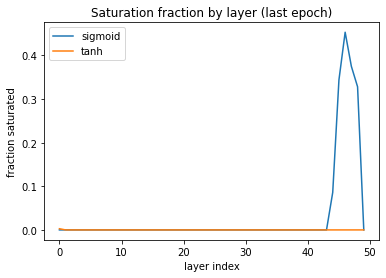

In [18]:
plt.figure()
for act in ["sigmoid", "tanh"]:
    act_stats = results[act]["hist"]["act_stats"][epoch_to_show]
    layers, means, vars_, sats = extract_layer_series(act_stats)
    plt.plot(layers, sats, label=act)
plt.xlabel("layer index")
plt.ylabel("fraction saturated")
plt.title("Saturation fraction by layer (last epoch)")
plt.legend()
plt.show()


## 8) Нормы градиентов по слоям

Смотрим нормы градиента весов каждого слоя на диагностическом батче.

Ожидаем:
- для sigmoid/tanh — быстрый спад градиентов к ранним слоям (vanishing gradients);
- для ReLU — градиент “проходит” заметно лучше.


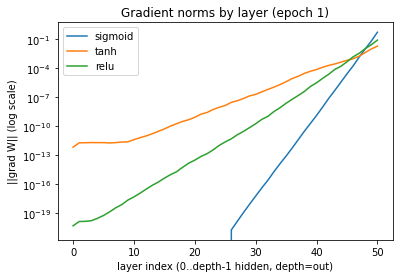

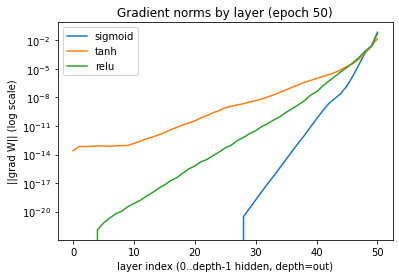

In [19]:
def plot_grad_norms(epoch_idx, title_suffix=""):
    plt.figure()
    for act in ["sigmoid", "tanh", "relu"]:
        g = results[act]["hist"]["grad_norms"][epoch_idx]
        # первые DEPTH — hidden, последний — out
        x = list(range(len(g)))
        plt.plot(x, g, label=act)
    plt.yscale("log")
    plt.xlabel("layer index (0..depth-1 hidden, depth=out)")
    plt.ylabel("||grad W|| (log scale)")
    plt.title(f"Gradient norms by layer {title_suffix}")
    plt.legend()
    plt.show()

plot_grad_norms(0, "(epoch 1)")
plot_grad_norms(epoch_to_show, f"(epoch {EPOCHS})")


## 9) Мини-вывод по наблюдениям

Сформулируйте после просмотра графиков:
- где именно (по глубине) начинается деградация распределений активаций;
- как быстро растёт доля насыщения для sigmoid/tanh;
- как ведут себя нормы градиентов по слоям;
- почему ReLU заметно облегчает оптимизацию в очень глубоких MLP.
